<a href="https://colab.research.google.com/github/dianakim0105/Score-based-Modelling-Diffusion-Modelling/blob/main/VE_Windkessel_Bayesian.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Exact posterior (tractable):
  mu_post  = 0.9600
  var_post = 0.2000
step   500 | loss 0.863732
step  1000 | loss 0.789196
step  1500 | loss 0.795194
step  2000 | loss 0.788239
step  2500 | loss 0.740045
step  3000 | loss 0.709312
step  3500 | loss 0.756389
step  4000 | loss 0.798721
step  4500 | loss 0.753886
step  5000 | loss 0.678576

Diagnostics vs exact noisy posterior score
   sigma        MSE        cosine
  1.0000    0.006728     0.9500
  0.3000    0.016635     0.9440
  0.1000    0.032331     0.9720
  0.0300    0.192316     0.9400

Sampling diagnostics vs exact posterior
Generated mean: 0.983141
True mean:      0.960000
Abs mean error: 0.023141

Generated var:  0.253899
True var:       0.200000
Abs var error:  0.053899


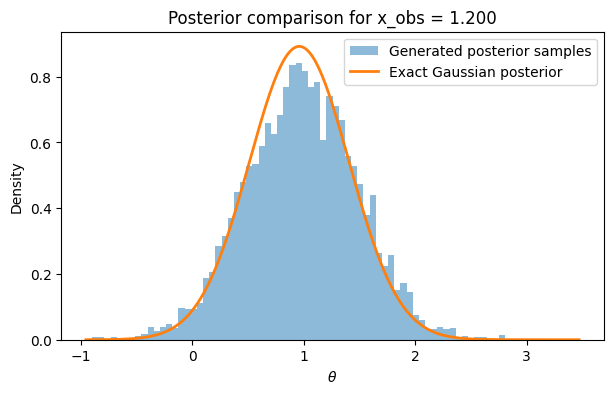

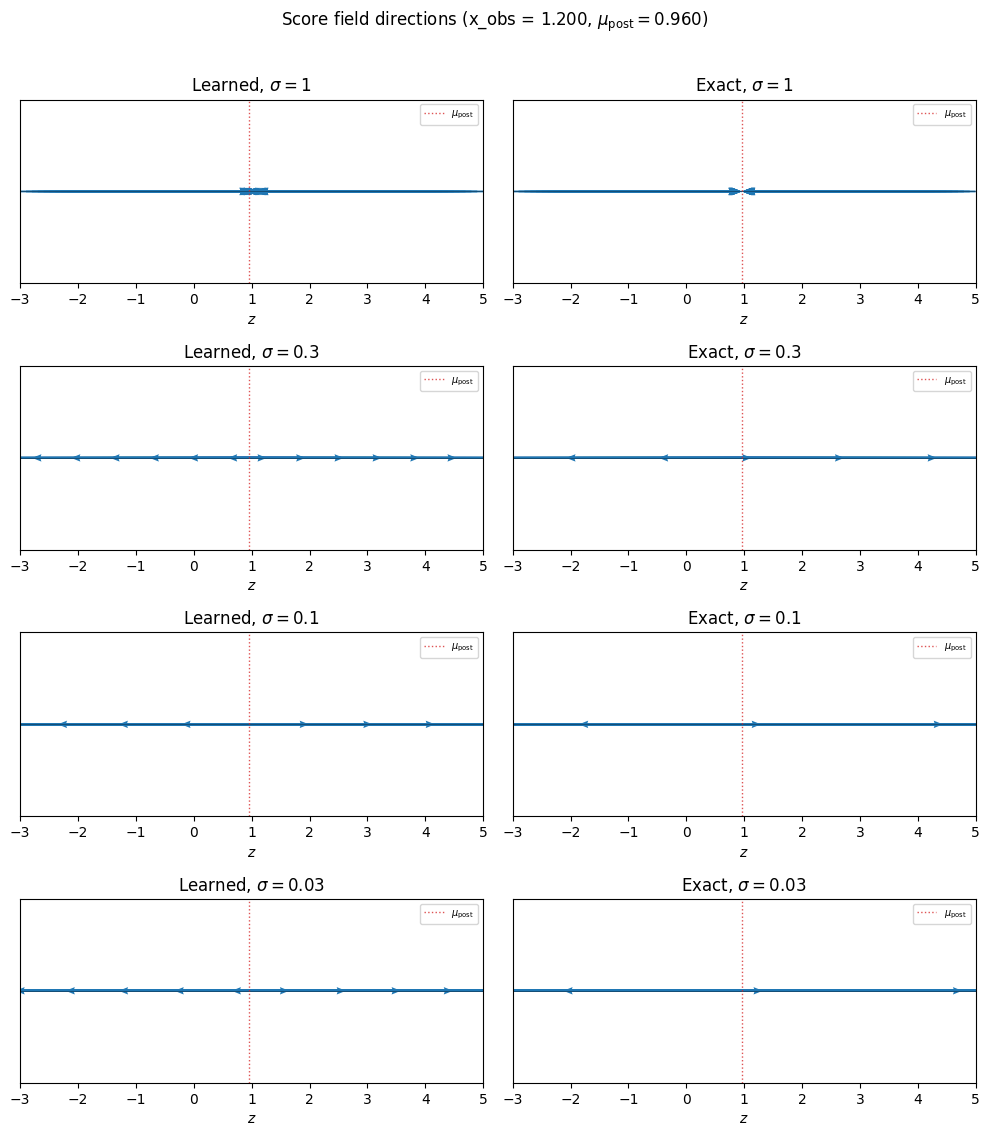

In [1]:
import numpy as np
import math
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt


# ============================================================
# Model (1D)
#   Prior:     theta ~ N(mu0, tau0^2)
#   Likelihood: x | theta ~ N(theta, sigma_lik^2)
#   Posterior: theta | x ~ N(mu_post, tau_post^2)   [conjugate]
#
#   tau_post^2 = 1 / (1/tau0^2 + 1/sigma_lik^2)
#   mu_post    = tau_post^2 * (mu0/tau0^2 + x/sigma_lik^2)
#
# VE noisy posterior (corruption z = theta + sigma * eps):
#   z | x ~ N(mu_post, tau_post^2 + sigma^2)
#   score = -(z - mu_post) / (tau_post^2 + sigma^2)
# ============================================================


# ============================================================
# 1) Simulator: Gaussian prior + Gaussian likelihood
# ============================================================
def sample_prior_gaussian(n_samples, mu0, tau0, device="cpu"):
    return torch.randn(n_samples, 1, device=device, dtype=torch.float32) * tau0 + mu0


def simulate_gaussian_likelihood(theta, sigma_lik):
    """
    theta: (N, 1)
    returns x: (N, 1), x | theta ~ N(theta, sigma_lik^2)
    """
    eps = torch.randn_like(theta)
    return theta + sigma_lik * eps


def sample_joint_prior_simulator(n_samples, mu0, tau0, sigma_lik, device="cpu"):
    theta = sample_prior_gaussian(n_samples, mu0, tau0, device=device)
    x = simulate_gaussian_likelihood(theta, sigma_lik)
    return theta, x


# ============================================================
# 2) Exact posterior (Gaussian-Gaussian conjugacy)
# ============================================================
def posterior_mean_var(x_obs, mu0, tau0, sigma_lik):
    """Scalar x_obs; returns (mu_post, var_post)."""
    x = float(x_obs)
    var0 = float(tau0) ** 2
    var_lik = float(sigma_lik) ** 2
    prec0 = 1.0 / var0
    prec_lik = 1.0 / var_lik
    var_post = 1.0 / (prec0 + prec_lik)
    mean_post = var_post * (prec0 * float(mu0) + prec_lik * x)
    return mean_post, var_post


def sample_exact_posterior(x_obs, mu0, tau0, sigma_lik, n_samples, device="cpu"):
    mean_post, var_post = posterior_mean_var(x_obs, mu0, tau0, sigma_lik)
    std_post = math.sqrt(var_post)
    return torch.randn(n_samples, 1, device=device, dtype=torch.float32) * std_post + mean_post


# ============================================================
# 3) MLP score network
#    input = (theta_t, x, log sigma)
#    output = scalar score in theta-direction
# ============================================================
class PosteriorScoreNet(nn.Module):
    def __init__(self, hidden_dim=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(3, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, 1),
        )

    def forward(self, theta_t, x, sigma):
        """
        theta_t: (B,1)
        x:       (B,1)
        sigma:   (B,) or (B,1)
        """
        if sigma.ndim == 1:
            sigma = sigma.unsqueeze(1)
        log_sigma = torch.log(sigma)
        inp = torch.cat([theta_t, x, log_sigma], dim=1)
        return self.net(inp)


# ============================================================
# 4) DSM training on joint (theta, x) from prior + simulator
# ============================================================
def train_bayesian_dsm(
    model,
    mu0,
    tau0,
    sigma_lik,
    sigmas,
    steps=5000,
    batch_size=256,
    lr=1e-3,
    sigma_weight=True,
    device="cpu",
):
    model.train()
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    sigmas_t = torch.tensor(sigmas, dtype=torch.float32, device=device)

    for step in range(1, steps + 1):
        theta0, x = sample_joint_prior_simulator(
            batch_size, mu0, tau0, sigma_lik, device=device
        )

        idx = torch.randint(0, len(sigmas_t), (batch_size,), device=device)
        sigma = sigmas_t[idx]

        eps = torch.randn_like(theta0)
        theta_t = theta0 + sigma.unsqueeze(1) * eps
        target = -eps / sigma.unsqueeze(1)

        pred = model(theta_t, x, sigma)

        if sigma_weight:
            w = (sigma ** 2).unsqueeze(1)
            loss = ((pred - target) ** 2 * w).mean()
        else:
            loss = ((pred - target) ** 2).mean()

        opt.zero_grad()
        loss.backward()
        opt.step()

        if step % 500 == 0:
            print(f"step {step:5d} | loss {loss.item():.6f}")

    return model


# ============================================================
# 5) Exact noisy posterior score (closed form, no MC)
#    z | x ~ N(mu_post, tau_post^2 + sigma^2)
# ============================================================
@torch.no_grad()
def exact_noisy_posterior_score(z, x_obs, mu0, tau0, sigma_lik, sigma, device="cpu"):
    """
    z:     (B, 1)
    x_obs: scalar observation
    sigma: float VE noise level
    """
    z = z.to(device)
    mu_post, var_post = posterior_mean_var(x_obs, mu0, tau0, sigma_lik)
    var_noisy = var_post + float(sigma) ** 2
    mu_t = torch.tensor(mu_post, dtype=torch.float32, device=device)
    return -(z - mu_t) / var_noisy


# ============================================================
# 6) Score diagnostics
# ============================================================
@torch.no_grad()
def eval_score_diagnostics(
    model,
    x_obs,
    mu0,
    tau0,
    sigma_lik,
    sigmas,
    n_test=2000,
    device="cpu",
):
    model.eval()

    mse_list = []
    cos_list = []
    sigma_list = []

    print("\nDiagnostics vs exact noisy posterior score")
    print("   sigma        MSE        cosine")

    for sigma in sigmas:
        sigma = float(sigma)

        theta0 = sample_exact_posterior(x_obs, mu0, tau0, sigma_lik, n_test, device=device)
        x = torch.full((n_test, 1), float(x_obs), dtype=torch.float32, device=device)

        eps = torch.randn_like(theta0)
        z = theta0 + sigma * eps

        sigma_batch = torch.full((n_test,), sigma, dtype=torch.float32, device=device)

        pred = model(z, x, sigma_batch)
        true = exact_noisy_posterior_score(
            z, x_obs, mu0, tau0, sigma_lik, sigma, device=device
        )

        mse = ((pred - true) ** 2).mean().item()
        cos = F.cosine_similarity(pred, true, dim=1).mean().item()

        sigma_list.append(sigma)
        mse_list.append(mse)
        cos_list.append(cos)

        print(f"{sigma:8.4f}  {mse:10.6f}   {cos:8.4f}")

    return sigma_list, mse_list, cos_list


# ============================================================
# 7) Predictor-Corrector sampler for p(theta | x_obs)
# ============================================================
@torch.no_grad()
def sample_posterior_pc(
    model,
    x_obs,
    mu0,
    tau0,
    sigma_lik,
    sigmas,
    n_samples=5000,
    n_corrector_steps=2,
    step_scale=1e-5,
    device="cpu",
    init_from_exact_noisy_marginal=True,
):
    model.eval()

    sigmas_t = torch.tensor(sigmas, dtype=torch.float32, device=device)
    sigma_max = sigmas_t.max().item()
    sigma_min = sigmas_t.min().item()

    x = torch.full((n_samples, 1), float(x_obs), dtype=torch.float32, device=device)

    if init_from_exact_noisy_marginal:
        theta0 = sample_exact_posterior(x_obs, mu0, tau0, sigma_lik, n_samples, device=device)
        z0 = torch.randn_like(theta0)
        theta = theta0 + sigma_max * z0
    else:
        theta = torch.randn(n_samples, 1, device=device) * sigma_max

    for i in range(len(sigmas_t) - 1):
        sigma_i = float(sigmas_t[i].item())
        sigma_next = float(sigmas_t[i + 1].item())

        sigma_batch_i = torch.full((n_samples,), sigma_i, dtype=torch.float32, device=device)

        score = model(theta, x, sigma_batch_i)
        delta = sigma_i**2 - sigma_next**2
        drift = delta * score
        noise = math.sqrt(max(delta, 0.0)) * torch.randn_like(theta)
        theta = theta + drift + noise

        sigma_batch_next = torch.full((n_samples,), sigma_next, dtype=torch.float32, device=device)

        for _ in range(n_corrector_steps):
            score = model(theta, x, sigma_batch_next)
            eta = step_scale * ((sigma_next / sigma_min) ** 2)
            theta = theta + eta * score + math.sqrt(2.0 * eta) * torch.randn_like(theta)

    return theta


# ============================================================
# 8) Sampling diagnostics
# ============================================================
@torch.no_grad()
def eval_sampling_diagnostics(samples, x_obs, mu0, tau0, sigma_lik):
    samples_np = samples.squeeze(1).cpu().numpy()

    mean_hat = float(np.mean(samples_np))
    var_hat = float(np.var(samples_np, ddof=0))

    mean_true, var_true = posterior_mean_var(x_obs, mu0, tau0, sigma_lik)

    mean_abs_error = abs(mean_hat - mean_true)
    var_abs_error = abs(var_hat - var_true)

    print("\nSampling diagnostics vs exact posterior")
    print(f"Generated mean: {mean_hat:.6f}")
    print(f"True mean:      {mean_true:.6f}")
    print(f"Abs mean error: {mean_abs_error:.6f}")
    print()
    print(f"Generated var:  {var_hat:.6f}")
    print(f"True var:       {var_true:.6f}")
    print(f"Abs var error:  {var_abs_error:.6f}")

    return {
        "mean_hat": mean_hat,
        "mean_true": mean_true,
        "mean_abs_error": mean_abs_error,
        "var_hat": var_hat,
        "var_true": var_true,
        "var_abs_error": var_abs_error,
    }


# ============================================================
# 9) Plot posterior samples vs exact Gaussian density
# ============================================================
@torch.no_grad()
def plot_posterior_comparison(samples, x_obs, mu0, tau0, sigma_lik, bins=80):
    samples_np = samples.squeeze(1).cpu().numpy()

    mu_post, var_post = posterior_mean_var(x_obs, mu0, tau0, sigma_lik)
    std_post = math.sqrt(var_post)

    lo = min(samples_np.min(), mu_post - 4 * std_post)
    hi = max(samples_np.max(), mu_post + 4 * std_post)
    grid = np.linspace(lo, hi, 500)
    pdf = (1.0 / (std_post * math.sqrt(2 * math.pi))) * np.exp(
        -0.5 * ((grid - mu_post) / std_post) ** 2
    )

    plt.figure(figsize=(7, 4))
    plt.hist(samples_np, bins=bins, density=True, alpha=0.5, label="Generated posterior samples")
    plt.plot(grid, pdf, linewidth=2, label="Exact Gaussian posterior")
    plt.xlabel(r"$\theta$")
    plt.ylabel("Density")
    plt.title(f"Posterior comparison for x_obs = {x_obs:.3f}")
    plt.legend()
    plt.show()


# ============================================================
# 10) Score field on a 1D grid (learned + exact)
# ============================================================
@torch.no_grad()
def _scores_on_1d_grid(model, x_obs, mu0, tau0, sigma_lik, sigma, theta_min, theta_max, n_grid, device):
    grid = torch.linspace(theta_min, theta_max, n_grid, device=device).unsqueeze(1)
    x = torch.full((n_grid, 1), float(x_obs), dtype=torch.float32, device=device)
    sigma_batch = torch.full((n_grid,), float(sigma), dtype=torch.float32, device=device)
    pred = model(grid, x, sigma_batch).squeeze(1).cpu().numpy()
    true = exact_noisy_posterior_score(
        grid, x_obs, mu0, tau0, sigma_lik, float(sigma), device=device
    ).squeeze(1).cpu().numpy()
    return grid.squeeze(1).cpu().numpy(), pred, true


def _plot_1d_score_quiver(ax, z, score, title, mu_post=None):
    """Horizontal arrows: score > 0 pushes right (+z), score < 0 pushes left."""
    y0 = np.zeros_like(z)
    vmax = max(float(np.max(np.abs(score))), 1e-8)
    ax.quiver(
        z,
        y0,
        score,
        np.zeros_like(score),
        angles="xy",
        scale_units="xy",
        scale=1.0 / (0.35 * vmax),
        width=0.004,
        headwidth=4,
        headlength=5,
        color="C0",
    )
    ax.axhline(0.0, color="black", linewidth=0.6, alpha=0.4)
    if mu_post is not None:
        ax.axvline(mu_post, color="C3", linewidth=1.0, linestyle=":", alpha=0.8, label=r"$\mu_{\mathrm{post}}$")
    ax.set_xlim(z.min(), z.max())
    ax.set_ylim(-0.6, 0.6)
    ax.set_xlabel(r"$z$")
    ax.set_yticks([])
    ax.set_title(title)
    if mu_post is not None:
        ax.legend(loc="upper right", fontsize=7)


# ============================================================
# 11) Plot learned vs exact noisy score fields (directions) for one sigma
# ============================================================
@torch.no_grad()
def plot_score_comparison_1d(
    model,
    x_obs,
    mu0,
    tau0,
    sigma_lik,
    sigma,
    theta_min=-3.0,
    theta_max=5.0,
    n_grid=80,
    device="cpu",
):
    model.eval()
    mu_post, _ = posterior_mean_var(x_obs, mu0, tau0, sigma_lik)
    grid_np, pred, true = _scores_on_1d_grid(
        model, x_obs, mu0, tau0, sigma_lik, sigma, theta_min, theta_max, n_grid, device
    )

    fig, axes = plt.subplots(1, 2, figsize=(10, 3.5), sharex=True)
    _plot_1d_score_quiver(
        axes[0], grid_np, pred, f"Learned (sigma={float(sigma):.3g})", mu_post=mu_post
    )
    _plot_1d_score_quiver(
        axes[1], grid_np, true, f"Exact (sigma={float(sigma):.3g})", mu_post=mu_post
    )
    fig.suptitle(f"Noisy posterior score field, x_obs = {x_obs:.3f}", y=1.02)
    fig.tight_layout()
    plt.show()


# ============================================================
# 12) Plot learned vs exact score fields for multiple sigma levels
# ============================================================
@torch.no_grad()
def plot_score_comparison_sigmas(
    model,
    x_obs,
    mu0,
    tau0,
    sigma_lik,
    sigmas,
    theta_min=-3.0,
    theta_max=5.0,
    n_grid=80,
    device="cpu",
):
    """One row per sigma: learned quiver (left) vs exact quiver (right)."""
    model.eval()
    sigmas = [float(s) for s in sigmas]
    mu_post, _ = posterior_mean_var(x_obs, mu0, tau0, sigma_lik)
    n_sig = len(sigmas)

    fig, axes = plt.subplots(n_sig, 2, figsize=(10, 2.8 * n_sig), squeeze=False)

    for i, sigma in enumerate(sigmas):
        grid_np, pred, true = _scores_on_1d_grid(
            model, x_obs, mu0, tau0, sigma_lik, sigma, theta_min, theta_max, n_grid, device
        )
        _plot_1d_score_quiver(
            axes[i, 0],
            grid_np,
            pred,
            rf"Learned, $\sigma={sigma:.4g}$",
            mu_post=mu_post,
        )
        _plot_1d_score_quiver(
            axes[i, 1],
            grid_np,
            true,
            rf"Exact, $\sigma={sigma:.4g}$",
            mu_post=mu_post,
        )

    fig.suptitle(
        f"Score field directions (x_obs = {x_obs:.3f}, "
        rf"$\mu_{{\mathrm{{post}}}} = {mu_post:.3f}$)",
        y=1.01,
    )
    fig.tight_layout()
    plt.show()


# ============================================================
# 13) Main experiment
# ============================================================
def run_gaussian_bayesian_experiment():
    device = "cuda" if torch.cuda.is_available() else "cpu"
    torch.manual_seed(0)
    np.random.seed(0)

    # Prior: theta ~ N(mu0, tau0^2)
    mu0 = 0.0
    tau0 = 1.0

    # Likelihood: x | theta ~ N(theta, sigma_lik^2)
    sigma_lik = 0.5

    # One observed datum
    x_obs = 1.2

    mu_post, var_post = posterior_mean_var(x_obs, mu0, tau0, sigma_lik)
    print("Exact posterior (tractable):")
    print(f"  mu_post  = {mu_post:.4f}")
    print(f"  var_post = {var_post:.4f}")

    sigmas = np.geomspace(1.0, 0.02, 20).astype(np.float32)
    score_plot_sigmas = [1.0, 0.3, 0.1, 0.03]

    model = PosteriorScoreNet(hidden_dim=64).to(device)

    train_bayesian_dsm(
        model=model,
        mu0=mu0,
        tau0=tau0,
        sigma_lik=sigma_lik,
        sigmas=sigmas,
        steps=5000,
        batch_size=256,
        lr=1e-3,
        sigma_weight=True,
        device=device,
    )

    eval_score_diagnostics(
        model=model,
        x_obs=x_obs,
        mu0=mu0,
        tau0=tau0,
        sigma_lik=sigma_lik,
        sigmas=score_plot_sigmas,
        n_test=1000,
        device=device,
    )

    posterior_samples = sample_posterior_pc(
        model=model,
        x_obs=x_obs,
        mu0=mu0,
        tau0=tau0,
        sigma_lik=sigma_lik,
        sigmas=sigmas,
        n_samples=5000,
        n_corrector_steps=2,
        step_scale=1e-5,
        device=device,
        init_from_exact_noisy_marginal=True,
    )

    eval_sampling_diagnostics(
        posterior_samples,
        x_obs=x_obs,
        mu0=mu0,
        tau0=tau0,
        sigma_lik=sigma_lik,
    )

    plot_posterior_comparison(
        posterior_samples,
        x_obs=x_obs,
        mu0=mu0,
        tau0=tau0,
        sigma_lik=sigma_lik,
        bins=80,
    )

    plot_score_comparison_sigmas(
        model=model,
        x_obs=x_obs,
        mu0=mu0,
        tau0=tau0,
        sigma_lik=sigma_lik,
        sigmas=score_plot_sigmas,
        theta_min=-3.0,
        theta_max=5.0,
        n_grid=80,
        device=device,
    )

    return model


if __name__ == "__main__":
    run_gaussian_bayesian_experiment()